# <a id="#">Task 3 – Mean, median, and Gaussian filtering</a>

In [6]:
import numpy as np
import matplotlib.pyplot as plt

---

## Linear filtering by convolution (mean filter)

**<a id="#">Task 3.1.1.</a>** Load the image `data/astronaut.png` and show it:

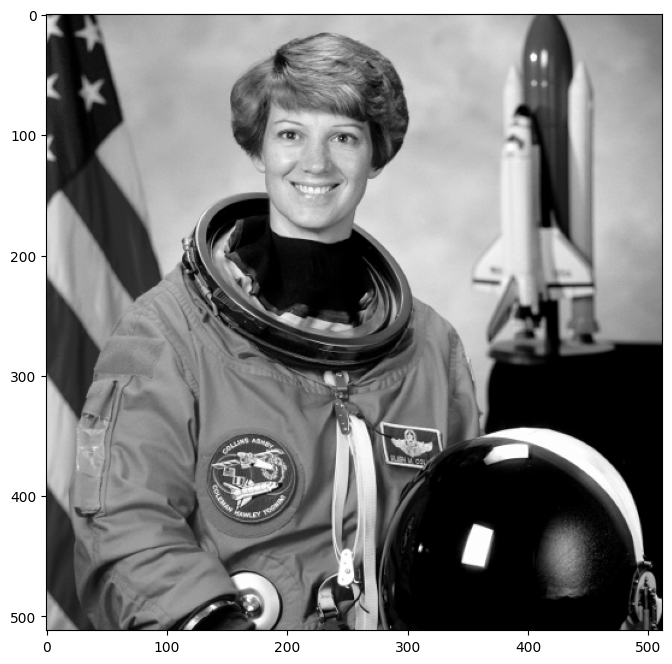

In [7]:
img = plt.imread('data/astronaut.png')
plt.figure(figsize=(15,8))
plt.imshow(img, 'gray')

**<a id="#">Task 3.1.2.</a>** Implement a mean filter:

In [ ]:
def meanfilter(img_in, size):

    result = np.zeros(img_in.shape)

    n = (size - 1) // 2

    for p in np.ndindex(img_in.shape):
        neighborhood_sum = 0
        counts  = 0
        if p[0] >= n and p[1] >= n and p[0] < img_in.shape[0] - n and p[1] < img_in.shape[1] -n :
          
            for q in np.ndindex(size, size):
                i = (p[0] + q[0]) - n
                j = (p[1] + q[1]) - n
                neighborhood_sum += img_in[i,j]
                counts += 1
            result[p] = neighborhood_sum / counts
            
    return result


**<a id="#">Task 3.1.3.</a>** Test your implementation from above by using the function `meanfilter` for the previously loaded image and show the result:

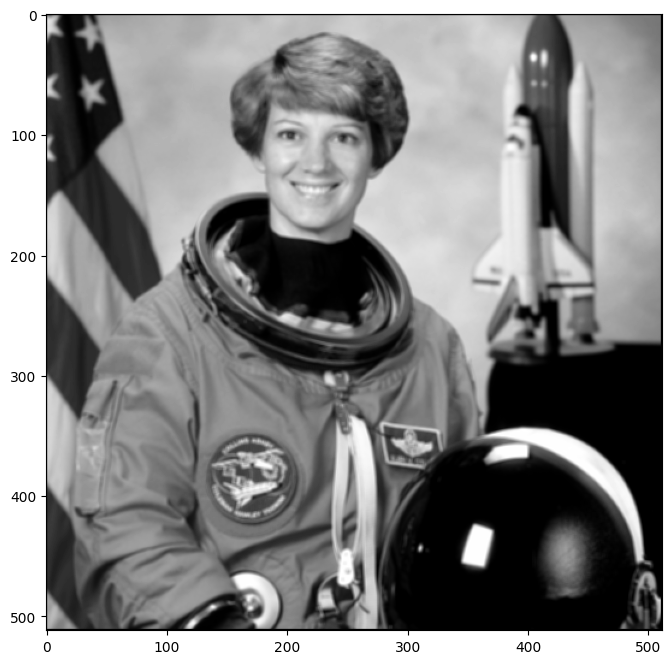

In [9]:
plt.figure(figsize=(15,8))
img0 = plt.imshow(meanfilter(img, 3), 'gray')

**<a id="#">Task 3.1.4.</a>** Compare your result for filter size `5` with the correct result image `data/astronaut_meanfilter5.png`:

In [10]:
img1= plt.imread('data/astronaut_meanfilter5.png')
img2 = meanfilter(img, 5)

diff = numpy.abs(img1 - img2)
print("Maximale Differenz:", diff.max())
print("Durchschnittliche Differenz:", diff.mean())


assert numpy.allclose(img1,img2, atol=1/255 )

Maximale Differenz: 7.362365722629605e-06
Durchschnittliche Differenz: 3.4405469688221417e-06


---

## Non-linear filtering

**<a id="#">Task 3.2.1.</a>** Implement a median filter:

In [11]:
def medianfilter(img_in, size):
    result = np.zeros(img_in.shape)

    n = (size - 1) // 2

    for p in np.ndindex(img_in.shape):
        median_list = []
        
        if p[0] >= n and p[1] >= n and p[0] < img_in.shape[0] - n and p[1] < img_in.shape[1] -n :
            
            for q in np.ndindex(size, size):
                i = (p[0] + q[0]) - n
                j = (p[1] + q[1]) - n
                median_list.append(img_in[i,j])
                median_list.sort()
                m = len(median_list)
                if m % 2 ==0:
                    median = (median_list[m // 2 - 1]+ median_list[m // 2]) / 2
                else:
                    median = median_list[m // 2]
            result[p] = median
        
    return result

**<a id="#">Task 3.2.2.</a>** First, test your implementation from above by using the function `medianfilter` for the previously loaded image and show the result:

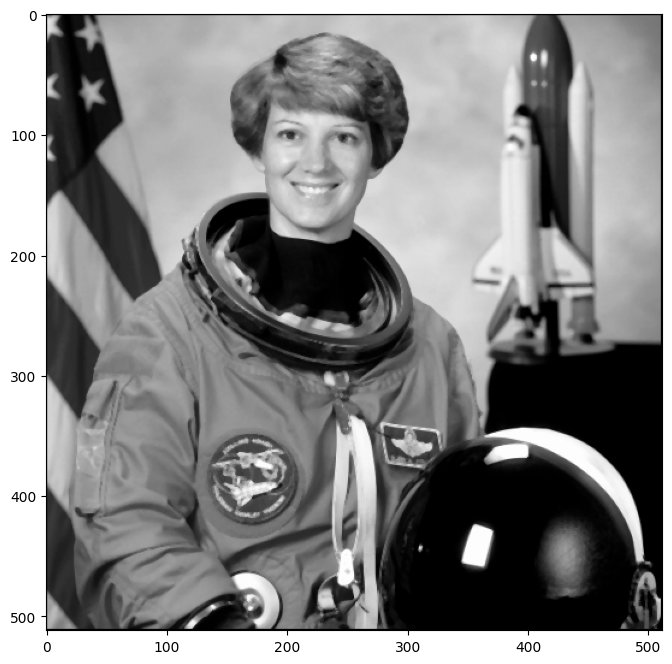

In [12]:
plt.figure(figsize=(15,8))
img3 = plt.imshow(medianfilter(img, 3), 'gray')

Then, compare your result for filter size `5` with the correct result image `data/astronaut_medianfilter5.png`:

In [14]:
img4= plt.imread('data/astronaut_medianfilter5.png')
img5= medianfilter(img,5)
assert numpy.allclose(img4,img5, atol=1/255 )

---

## Using pre-implemented filters

**<a id="#">Task 3.3.1.</a>** Load the package `scipy.ndimage`:

In [15]:
import scipy.ndimage

**<a id="#">Task 3.3.2 (a).</a>** Apply a **mean filter** from `scipy.ndimage` to the loaded image:

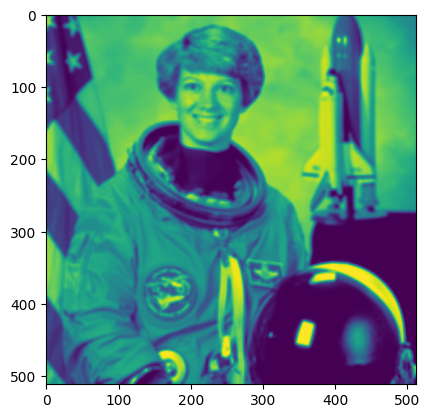

In [16]:
plt.imshow(scipy.ndimage.uniform_filter(img, 5))


**<a id="#">Task 3.3.2 (b).</a>** Apply a **median filter** from `scipy.ndimage` to the loaded image:

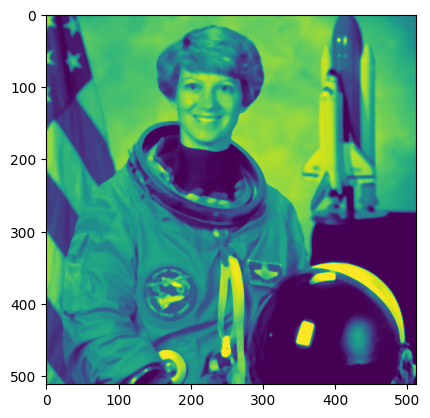

In [17]:
plt.imshow(scipy.ndimage.median_filter(img, 5))

**<a id="#">Task 3.3.2 (c).</a>** Apply a **Gaussian filter** from `scipy.ndimage` to the loaded image:

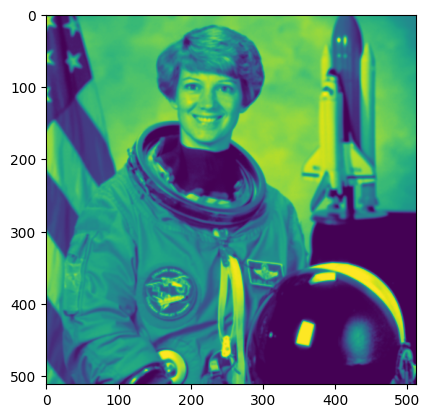

In [19]:
plt.imshow(scipy.ndimage.gaussian_filter(img, 1))

**<a id="#">Task 3.3.3.</a>** Compare the results obtained using the functions from `scipy.ndimage` with those you obtained using your own implementations. What are the main differences? Do you have an explanation?

In [21]:
diff = numpy.abs(scipy.ndimage.median_filter(img, 5) - img5)
print("Maximale Differenz:", diff.max())
print("Durchschnittliche Differenz:", diff.mean())


Maximale Differenz: 0.8901960849761963
Durchschnittliche Differenz: 0.006383454722222126


---

## Slicing and benchmarking

**<a id="#">Task 3.4.2.</a>** Implement either a mean filter or a median filter using only a single `for`-loop:

In [ ]:
def fastfilter(img_in, size):
    ...

**<a id="#">Task 3.4.3.</a>** First, test your implementation from above by using the function `fastfilter` for the previously loaded image and show the result:

Then, compare your result to those obtained using your implementation for either `meanfilter` or `medianfilter`, respectively:

**<a id="#">Task 3.4.4.</a>** Benchmark the code run times:

**<a id="#">Task 3.4.5.</a>** Document your observations regarding the benchmarking results and try to think of an explanation: